<a href="https://colab.research.google.com/github/NaufalPratomo/PCVK_Ganjil_2025/blob/main/Modul9_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Impor Library**

In [27]:
!pip install opencv-python matplotlib scikit-learn
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

**Percobaan 1 - Jenis-Jenis Thresholding Dasar**

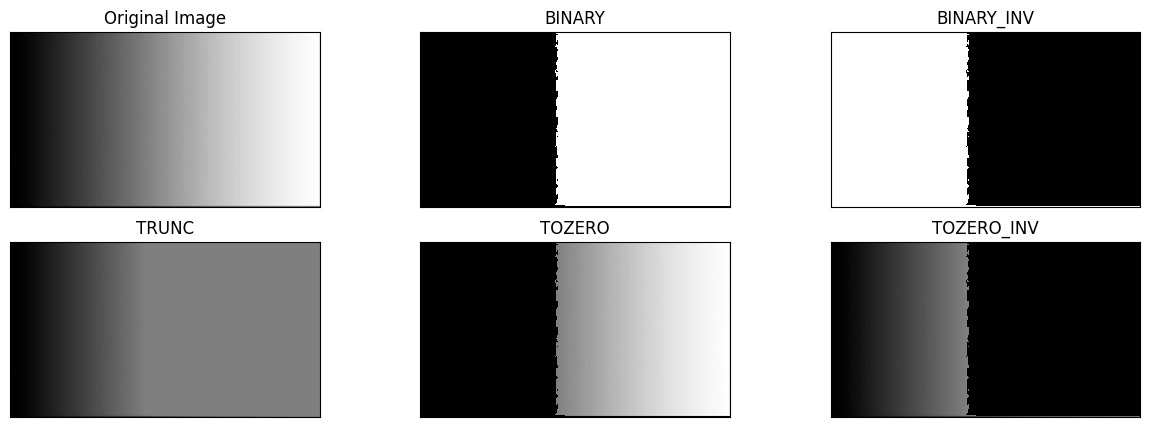

In [28]:
# Tentukan path file gambar
filename = 'gradient.jpg'

# Baca gambar
img = cv.imread(filename)

# Tentukan nilai threshold
thresh = 127

# 1. Binary Threshold
ret,thresh1 = cv.threshold(img,thresh,255,cv.THRESH_BINARY)

# 2. Binary Threshold Inverse
ret,thresh2 = cv.threshold(img,thresh,255,cv.THRESH_BINARY_INV)

# 3. Threshold Truncate
ret,thresh3 = cv.threshold(img,thresh,255,cv.THRESH_TRUNC)

# 4. Threshold Tozero
ret,thresh4 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO)

# 5. Threshold Tozero Inverse
ret,thresh5 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO_INV)

# Siapkan judul dan gambar untuk plotting
titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

# Tampilkan hasil menggunakan Matplotlib
plt.figure(figsize = (15,5))
for i in range(len(images)):
  plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])

plt.show()

**Percobaan 2 - Global vs. Adaptive Thresholding**

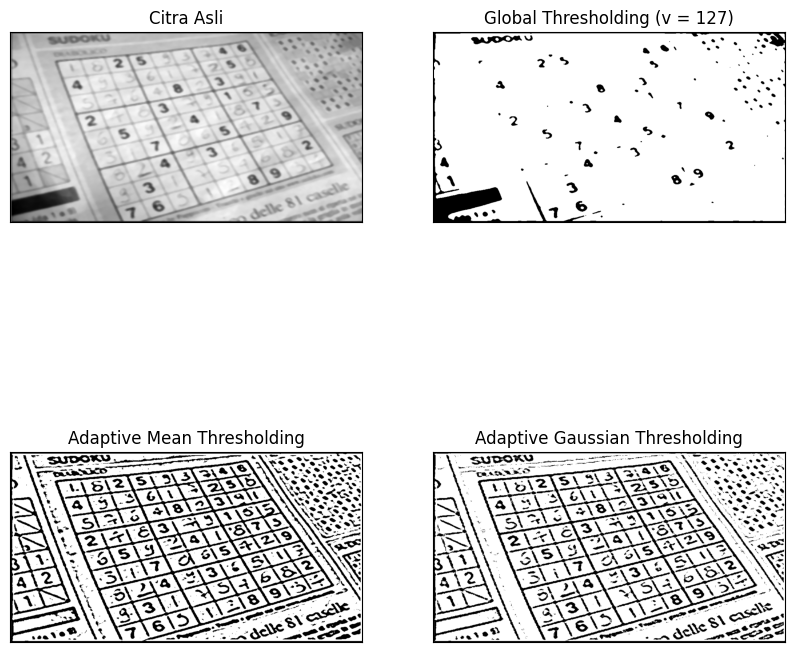

In [29]:
# Tentukan path file gambar
filename = 'sudoku.jpg'
# Baca gambar, terapkan median blur, dan konversi ke grayscale
citra = cv.medianBlur(cv.imread(filename),5)
gray = cv.cvtColor(citra, cv.COLOR_BGR2GRAY)

# Tentukan nilai threshold global
thresh = 127

# 1. Global Thresholding (nilai v = 127)
ret,th1 = cv.threshold(gray,thresh,255,cv.THRESH_BINARY)

# 2. Adaptive Mean Thresholding
th2 = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_MEAN_C, \
                           cv.THRESH_BINARY,11,2)

# 3. Adaptive Gaussian Thresholding
th3 = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C, \
                           cv.THRESH_BINARY,11,2)

# Siapkan judul dan gambar untuk plotting
titles = ['Citra Asli', 'Global Thresholding (v = 127)', \
          'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
citra2 = [gray, th1, th2, th3]

# Tampilkan hasil
plt.figure(figsize = (10,10))
for i in range(len(citra2)):
  plt.subplot(2,2,i+1),plt.imshow(citra2[i],'gray')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])

plt.show()

**Percobaan 3 - Otsu's Thresholding**

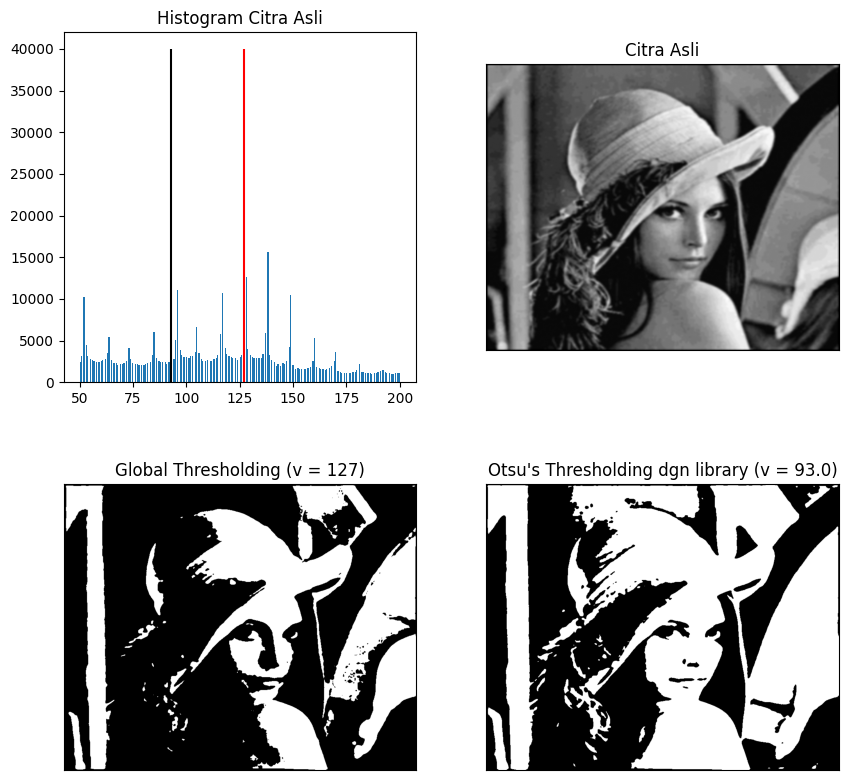

In [33]:
# Tentukan path file gambar
filename = 'lena_gs_lc2.jpg'

# Baca gambar dalam mode grayscale (parameter 0)
img = cv.imread(filename,0)

# Terapkan Gaussian blur
blur = cv.GaussianBlur(img,(5,5),0)

# Tentukan nilai threshold global
thresh = 127

# 1. Global Thresholding (v = 127)
ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)

# 2. Otsu's Thresholding
# Perhatikan bahwa nilai threshold (parameter kedua) diisi 0,
# karena nilainya akan dihitung otomatis oleh Otsu
ret2,th2 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

# Siapkan judul dan gambar untuk plotting
x = ("Otsu's Thresholding dgn library (v = ")+str(ret2)+")"
titles = ['Citra Asli', 'Global Thresholding (v = 127)', x]
citra3 = [blur, th1, th2]

plt.figure(figsize = (10,10))

# Plot histogram
plt.subplot(2,2,1)
plt.hist(blur.ravel(),256,range=[50,200]) # Hati-hati dengan deprecation warning, tapi tetap berjalan
plt.vlines(thresh,0,40000,colors='red') # Garis threshold global (127)
plt.vlines(ret2,0,40000,colors='black') # Garis threshold Otsu (hasil otomatis)
plt.title('Histogram Citra Asli')

# Plot gambar
for i in range(len(citra3)):
  plt.subplot(2,2,i+2),plt.imshow(citra3[i],'gray')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])

plt.show()

**Percobaan 4 - Segmentasi Warna dengan K-Means Clustering**

Klaster ke-2 terdeteksi sebagai kuning: [249 206   3]


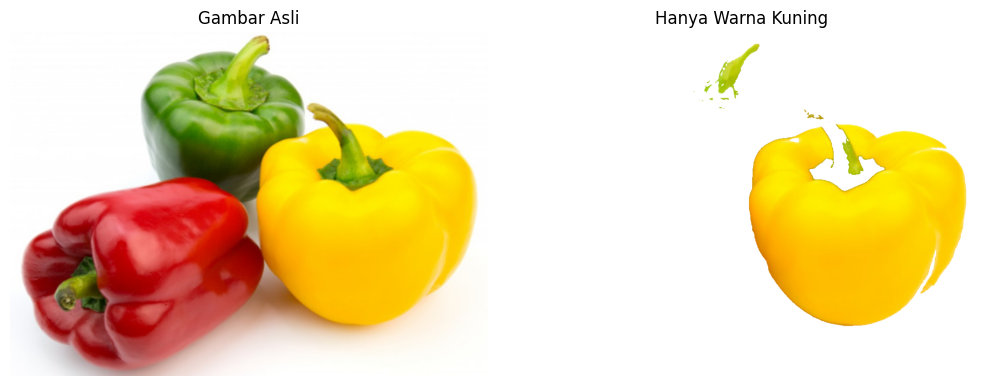

In [31]:
# Tentukan path file gambar
file_path = 'peppers.jpg'
# Baca gambar dan konversi dari BGR (OpenCV) ke RGB (Matplotlib)
img = cv.imread(file_path)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Ubah (reshape) data gambar menjadi daftar piksel (baris, 3 kolom [R,G,B])
pixels = img_rgb.reshape(-1, 3)

# Tentukan jumlah klaster (k)
k = 5

# Terapkan K-Means clustering
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init=10 untuk menekan warning
kmeans.fit(pixels)

# Dapatkan pusat klaster (warna dominan) dan label untuk setiap piksel
cluster_centers = kmeans.cluster_centers_.astype(int)
labels = kmeans.labels_

# Buat fungsi sederhana untuk mendeteksi warna kuning
def is_yellow(color):
  r, g, b = color
  # Logika: R tinggi, G tinggi, B rendah
  return r > 150 and g > 150 and b < 100

# Cari klaster mana yang mewakili warna kuning
yellow_cluster = None
for idx, center in enumerate(cluster_centers):
  if is_yellow(center):
    yellow_cluster = idx
    print(f"Klaster ke-{idx} terdeteksi sebagai kuning: {center}")
    break

if yellow_cluster is None:
  print("Tidak ditemukan klaster warna kuning.")
else:
  # Buat gambar baru hanya dengan piksel kuning
  mask = (labels == yellow_cluster)
  yellow_pixels = np.zeros_like(pixels)
  yellow_pixels[mask] = pixels[mask]
  yellow_img = yellow_pixels.reshape(img_rgb.shape)

  # Ubah latar belakang hitam (default dari np.zeros_like) menjadi putih
  white_bg = yellow_img.copy()
  white_bg[np.all(white_bg == [0, 0, 0], axis=-1)] = [255, 255, 255]

  # Tampilkan gambar asli dan hasil segmentasi
  fig, axes = plt.subplots(1, 2, figsize=(10, 5))
  axes[0].imshow(img_rgb)
  axes[0].set_title("Gambar Asli")
  axes[0].axis('off')

  axes[1].imshow(white_bg)
  axes[1].set_title("Hanya Warna Kuning")
  axes[1].axis('off')

  plt.tight_layout()
  plt.show()

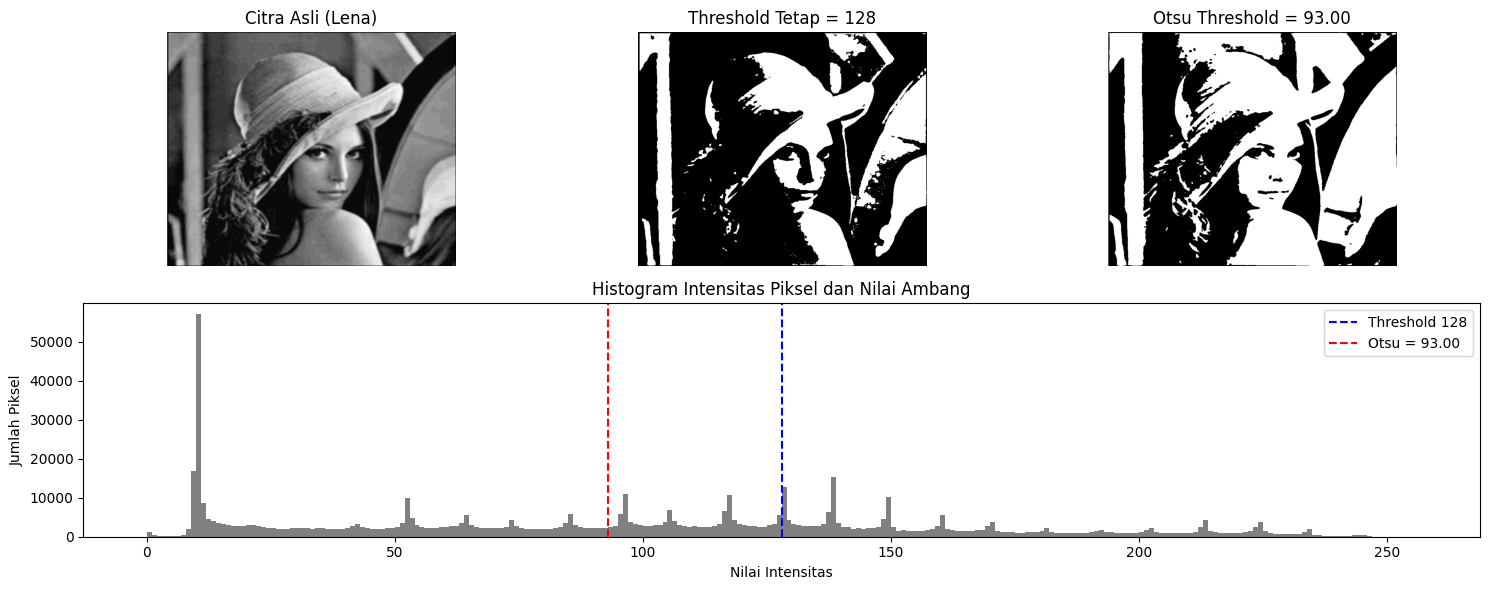

In [32]:
# 1. Membaca citra Lena dalam mode grayscale
file_path = 'lena_gs_lc2.jpg'
image = cv.imread(filename, cv.IMREAD_GRAYSCALE)

# 2. Pastikan gambar berhasil dibaca
if image is None:
    print("Gambar tidak ditemukan. Pastikan file 'lena.png' ada di direktori kerja.")
else:
    # --- Metode 1: Threshold tetap 128 ---
    threshold_value = 128
    _, segmented_fixed = cv.threshold(image, threshold_value, 255, cv.THRESH_BINARY)

    # --- Metode 2: Otsu Thresholding ---
    otsu_value, segmented_otsu = cv.threshold(image, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

    # 3. Tampilkan hasil segmentasi
    plt.figure(figsize=(15,6))

    # Gambar asli
    plt.subplot(2,3,1)
    plt.imshow(image, cmap='gray')
    plt.title('Citra Asli (Lena)')
    plt.axis('off')

    # Segmentasi Threshold 128
    plt.subplot(2,3,2)
    plt.imshow(segmented_fixed, cmap='gray')
    plt.title(f'Threshold Tetap = {threshold_value}')
    plt.axis('off')

    # Segmentasi Otsu
    plt.subplot(2,3,3)
    plt.imshow(segmented_otsu, cmap='gray')
    plt.title(f'Otsu Threshold = {otsu_value:.2f}')
    plt.axis('off')

    # Histogram citra asli
    plt.subplot(2,1,2)
    plt.hist(image.ravel(), bins=256, range=(0,256), color='gray')
    plt.axvline(x=threshold_value, color='blue', linestyle='--', label=f'Threshold 128')
    plt.axvline(x=otsu_value, color='red', linestyle='--', label=f'Otsu = {otsu_value:.2f}')
    plt.title('Histogram Intensitas Piksel dan Nilai Ambang')
    plt.xlabel('Nilai Intensitas')
    plt.ylabel('Jumlah Piksel')
    plt.legend()
    plt.tight_layout()
    plt.show()